Reason to use Stripe 82 with ZTF, covers the area around the celestial equator which is accessible to most ground based telescopes and good for transient/ variability detection.
- RA: −50° to +60°
- DEC: −1.25° to +1.25°

In [ ]:
# Installations
# %pip install astroquery astropy pandas numpy
# %pip install ztfquery

## Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from io import StringIO
import requests
from astropy.coordinates import SkyCoord
from astropy import units as u


## Preprocessing data 

#### Using Glade+ Catalog (queries, csv conversion)

In [3]:
# Checking the catalogs in GLADE+
from astroquery.esasky import ESASky

catalog_list = ESASky.list_catalogs()
print(catalog_list)

['TYCHO-2', '2RXS', 'ALLWISE', 'PLANCK-PSZ2', 'PLANCK-PCCS2-LFI', 'PLANCK-PCCS2-HFI', 'XMM-SLEW', 'GAIA-DR3', 'PLANCK-PGCC', 'INTEGRAL', 'HIPPARCOS-2', 'PLANCK-PCCS2E-HFI', 'HERSCHEL-SPSC-350', 'XMM-EPIC', 'HERSCHEL-SPSC-250', 'HERSCHEL-HPPSC-160', 'HERSCHEL-HPPSC-100', 'HERSCHEL-HPPSC-070', 'AKARI-IRC-SC', 'OU_BLAZARS', 'TWOMASS', 'HERSCHEL-SPSC-500', 'EROSITA-EFEDS-MAIN', 'EROSITA-EFEDS-HARD', 'EUCLID-MER', 'CHANDRA-SC21', 'XMM-EPIC-STACK', 'XMM-OM', 'HCV', 'FERMI_3FHL', 'FERMI_4FGL-DR2', 'EROSITA-ETACHA-MAIN', 'SWIFT-2SXPS', 'EROSITA-ETACHA-HARD', 'FERMI_4LAC-DR2', 'ICECUBE', 'HSC', 'PLATO ASPIC1.1', '2WHSP', 'GAIA-FPR', 'EROSITA-ERASS-HARD', 'EROSITA-ERASS-MAIN', 'GLADE+', 'LAMOST_MRS', 'LAMOST_LRS']


Converting txt to csv

In [ ]:
# # Convert GLADE_2.4.txt to GLADE_2.4.csv, assuming whitespace-delimited columns

# import pandas as pd

# # Read the whitespace-delimited text file
# df = pd.read_csv('glade+.txt', delim_whitespace=True, header=None)

# # Save as CSV
# df.to_csv('glade+.csv', index=False)
# print("Conversion complete: glade+.txt to glade+.csv")

In [ ]:
## Checks
#Print number of rows in GLADE+.txt
df = pd.read_csv('glade+.txt')
print(f"Number of rows in GLADE+.txt: {len(df)}")

# Read the file with whitespace delimiter
df = pd.read_csv('glade+.txt', delim_whitespace=True, header=None)

# Access column 9 (index 8) in the first row (index 0)
value = df.iloc[0, 8]
print(value)

Number of rows in GLADE+.txt: 23181757


#### Filtering for Stripe_82

In [ ]:
#Go through glade+.txt and create a new file glade+_stripe82.txt that only contains rows with declination between -1.25 and +1.25 degrees and right ascension between >=310 and <=60 degrees (based on 0-360 convention)

# Read without auto-interpreting 'null' as NaN
df = pd.read_csv('glade+.txt',
    delim_whitespace=True,
    header=None,
    keep_default_na=False,  # do not convert to NaN
    na_values=[]            # no tokens treated as NA
)

# Apply the Stripe 82 filter (df[8] is RA, df[9] is Dec)
stripe82_df = df[((df[8] >= 310) | (df[8] <= 60)) &
                 (df[9] >= -1.25) & (df[9] <= 1.25)]

# Write out in a whitespace-like format (tabs here)
stripe82_df.to_csv(
    'glade+_stripe82.txt',
    sep='\t',
    index=False,
    header=False
)

print("Filtered glade+_stripe82.txt created.")


In [3]:
#Go through glade+_stripe82.txt and create a new file glade+_stripe82.csv with the column headers listed below:

# Define column headers
column_headers = ["GLADE no","PGC no","GWGC name","HyperLEDA name","2MASS name","WISExSCOS name","SDSS-DR16Q name","Object type flag","RA","Dec","B","B_err","B flag","B_Abs","J","J_err","H","H_err","K","K_err","W1","W1_err","W2","W2_err","W1 flag","B_J","B_J err","z_helio","z_cmb","z flag","v_err","z_err","d_L","d_L err","dist flag","M*","M*_err","M* flag","Merger rate","Merger rate error"]

# Read the filtered text file
stripe82_df = pd.read_csv('glade+_stripe82.txt', delim_whitespace=True, header=None)

# Assign column headers
stripe82_df.columns = column_headers
# Save as CSV
stripe82_df.to_csv('glade+_stripe82.csv', index=False)
print("Conversion complete: glade+_stripe82.txt to glade+_stripe82.csv")

#Print number of rows in glade+_stripe82.csv
df_stripe82 = pd.read_csv('glade+_stripe82.csv')
print(f"Number of rows in glade+_stripe82.csv: {len(df_stripe82)}")


/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_45281/4183209458.py:7: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  stripe82_df = pd.read_csv('glade+_stripe82.txt', delim_whitespace=True, header=None)


Conversion complete: glade+_stripe82.txt to glade+_stripe82.csv
Number of rows in glade+_stripe82.csv: 273917


/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_45281/4183209458.py:16: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stripe82 = pd.read_csv('glade+_stripe82.csv')


### HyperLEDA

In [ ]:
#Print number of rows in HyperLeda.txt
df2 = pd.read_csv('HyperLeda.txt')
print(f"Number of rows in HyperLeda.txt: {len(df2)}")


Number of rows in HyperLeda.txt: 429337


In [ ]:
import pandas as pd
import numpy as np

input_file = "HyperLeda.txt"
output_file = "HyperLeda.csv"

colnames = [
    "pgc",
    "objname",
    "objecttype",
    "al2000",
    "de2000",
    "agnclass",
    "t",
    "bt",
    "vrad",
    "incl",
    "mabs"
]

colspecs = [
    (0, 10),    # pgc
    (12, 43),   # objname
    (44, 46),   # objecttype (ob)
    (47, 64),   # al2000
    (65, 82),   # de2000
    (83, 98),   # agnclass
    (99, 107),  # t
    (108, 116), # bt
    (117, 125), # vrad
    (126, 134), # incl
    (135, 143)  # mabs
]

df2 = pd.read_fwf(
    input_file,
    colspecs=colspecs,
    names=colnames,
    comment="#",
    dtype=str
)

# Clean whitespace, preserve empty columns
for col in df2.columns:
    df2[col] = df2[col].str.strip().replace("", np.nan)

# Convert numerics
numeric_cols = ["al2000", "de2000", "t", "bt", "vrad", "incl", "mabs"]
df2[numeric_cols] = df2[numeric_cols].apply(pd.to_numeric, errors="coerce")

df2.to_csv(output_file, index=False)

print("CSV written correctly using ruler-defined columns.")
print(df2.head())



CSV written correctly using ruler-defined columns.
      pgc     objname objecttype     al2000    de2000         agnclass  \
0    3951   PGC039514          G  12.304273 -0.358328               18   
1    5053   PGC050534          G  14.161206 -0.655800           2   15   
2   14034   PGC140343          G  14.617810  0.118101  S1            1   
3   21431   PGC214313          G  14.665624 -0.744171          10   16   
4  112334  PGC1123340          G  14.531327 -1.245697               18   

         t   bt   vrad   incl  mabs  
0  987.000  NaN -18.00   13.0   NaN  
1  891.000  6.0    NaN  876.0   NaN  
2    0.422  NaN    NaN    NaN   NaN  
3  859.000  NaN    NaN  267.0   NaN  
4  241.000  4.0   0.75    NaN   NaN  


In [ ]:
import pandas as pd
import numpy as np

input_file = "HyperLeda.txt"
output_file = "HyperLeda.csv"

colnames = [
    "pgc",
    "objname",
    "objecttype",
    "al2000",
    "de2000",
    "agnclass"
]

colspecs = [
    (0, 10),    # pgc
    (12, 43),   # objname
    (44, 46),   # objecttype (ob)
    (47, 64),   # al2000
    (65, 82),   # de2000
    (83, 85)   # agnclass
]

df2 = pd.read_fwf(
    input_file,
    colspecs=colspecs,
    names=colnames,
    comment="#",
    dtype=str
)

# Clean whitespace, preserve empty columns
for col in df2.columns:
    df2[col] = df2[col].str.strip().replace("", np.nan)

# Convert numerics
numeric_cols = ["al2000", "de2000"]
df2[numeric_cols] = df2[numeric_cols].apply(pd.to_numeric, errors="coerce")

df2.to_csv(output_file, index=False)

print("CSV written correctly using ruler-defined columns.")
print(df2.head())



CSV written correctly using ruler-defined columns.
      pgc     objname objecttype     al2000    de2000 agnclass
0    3951   PGC039514          G  12.304273 -0.358328      NaN
1    5053   PGC050534          G  14.161206 -0.655800      NaN
2   14034   PGC140343          G  14.617810  0.118101       S1
3   21431   PGC214313          G  14.665624 -0.744171      NaN
4  112334  PGC1123340          G  14.531327 -1.245697      NaN


In [ ]:
#Count number of populated rows in agnclass column i.e not NaN
import pandas as pd
df2 = pd.read_csv('HyperLeda.csv')
num_populated_agnclass = df2['agnclass'].notna().sum()
print(f"Number of populated rows in agnclass column: {num_populated_agnclass}")

Number of populated rows in agnclass column: 11740


## Crossmatching

In [5]:
#Go through HyperLeda.csv and crossmatch it with glade+_stripe82.csv based on RA = al2000 and Dec = de2000, and create a new file glade+_stripe82_hyperleda.csv that contains only the matched rows with all columns from HyperLeda.csv.
# Read the two CSV files
glade82_df = pd.read_csv('glade+_stripe82.csv')
hyperleda_df = pd.read_csv('HyperLeda.csv') 

# Create SkyCoord objects for both dataframes
glade_coords = SkyCoord(ra=glade82_df['RA'].values*u.degree,
                         dec=glade82_df['Dec'].values*u.degree)
hyperleda_coords = SkyCoord(ra=hyperleda_df['al2000'].values*u.degree,
                             dec=hyperleda_df['de2000'].values*u.degree)
# Perform crossmatch
idx, d2d, _ = glade_coords.match_to_catalog_sky(hyperleda_coords) # idx: indices of closest matches in hyperleda for each glade entry, d2d: on-sky distances
# Set a matching threshold (e.g., 3 arcsecond)
threshold = 3 * u.arcsec
matches = d2d < threshold
# Get matched rows
matched_glade = glade82_df[matches]
matched_hyperleda = hyperleda_df.iloc[idx[matches]].reset_index(drop=True)

# Combine matched dataframes
matched_hyperleda.to_csv('combined.csv', index=False)

print("Crossmatch complete: combined.csv created.")

/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_45281/1952180058.py:3: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  glade82_df = pd.read_csv('glade+_stripe82.csv')


Crossmatch complete: combined.csv created.
Number of rows in combined.csv: 839


In [6]:
df = pd.read_csv('combined.csv')
print(f"Number of rows in combined.csv: {len(df)}")

# print number of rows that are populated in agnclass column in combined.csv
num_populated_agnclass_combined = df['agnclass'].notna().sum()
print(f"Number of populated rows in agnclass column in combined.csv: {num_populated_agnclass_combined}")

Number of rows in combined.csv: 839
Number of populated rows in agnclass column in combined.csv: 33


In [10]:
### Trial without using skycoords for RA Dec comparison
import pandas as pd
import numpy as np
from scipy.spatial import cKDTree

# Read the two CSV files
glade82_df = pd.read_csv('glade+_stripe82.csv')
hyperleda_df = pd.read_csv('HyperLeda.csv')

# Build coordinate arrays (RA, Dec) in degrees
glade_coords = np.column_stack((glade82_df['RA'], glade82_df['Dec']))
hyperleda_coords = np.column_stack((hyperleda_df['al2000'], hyperleda_df['de2000']))

# Build KD-tree from HyperLeda coordinates
tree = cKDTree(hyperleda_coords) #KD-tree is a data structure that allows for efficient nearest-neighbor searches in multi-dimensional space. 

# Matching threshold (3 arcsec = 3 / 3600 degrees)
threshold = 5.0 / 3600.0

# Query nearest neighbors
distances, indices = tree.query(glade_coords, distance_upper_bound=threshold)

# Keep only valid matches
mask = distances != np.inf
matched_indices = indices[mask]

# Select matched HyperLeda rows only
matched_hyperleda = hyperleda_df.iloc[matched_indices].reset_index(drop=True)

# Save result
matched_hyperleda.to_csv('glade+_stripe82_hyperleda.csv', index=False)

print("Crossmatch complete: glade+_stripe82_hyperleda.csv created.")
print(f"Number of matched rows: {len(matched_hyperleda)}")

# print number of rows that are populated in agnclass column in glade+_stripe82_hyperleda.csv
df = pd.read_csv('glade+_stripe82_hyperleda.csv')
num_populated_agnclass_matched = df['agnclass'].notna().sum()
print(f"Number of populated rows in agnclass column in glade+_stripe82_hyperleda.csv: {num_populated_agnclass_matched}")


/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_45281/3216905732.py:7: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  glade82_df = pd.read_csv('glade+_stripe82.csv')


Crossmatch complete: glade+_stripe82_hyperleda.csv created.
Number of matched rows: 2289
Number of populated rows in agnclass column in glade+_stripe82_hyperleda.csv: 81


In [14]:
#Simple direct comparison of RA and Dec values without skycoords or KD-tree
import pandas as pd
# Read the two CSV files
glade82_df = pd.read_csv('glade+_stripe82.csv')
hyperleda_df = pd.read_csv('HyperLeda.csv')

#Rounding RA and Dec to 4 decimal places for matching
glade82_df['RA'] = glade82_df['RA'].round(3)
glade82_df['Dec'] = glade82_df['Dec'].round(3)
hyperleda_df['al2000'] = hyperleda_df['al2000'].round(3)
hyperleda_df['de2000'] = hyperleda_df['de2000'].round(3)

# Merge dataframes on RA and Dec
merged_df = pd.merge(glade82_df, hyperleda_df, left_on=['RA', 'Dec'], right_on=['al2000', 'de2000'])
# merged_df = pd.merge(hyperleda_df, glade82_df, left_on=['al2000', 'de2000'], right_on=['RA', 'Dec'])
# Save result
merged_df.to_csv('glade+_stripe82_hyperleda_direct.csv', index=False)
print("Direct match complete: glade+_stripe82_hyperleda_direct.csv created.")
print(f"Number of directly matched rows: {len(merged_df)}")
# print number of rows that are populated in agnclass column in glade+_stripe82_hyperleda_direct.csv
df = pd.read_csv('glade+_stripe82_hyperleda_direct.csv')
num_populated_agnclass_direct = df['agnclass'].notna().sum()
print(f"Number of populated rows in agnclass column in glade+_stripe82_hyperleda_direct.csv: {num_populated_agnclass_direct}")

/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_47853/3769484691.py:4: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  glade82_df = pd.read_csv('glade+_stripe82.csv')


Direct match complete: glade+_stripe82_hyperleda_direct.csv created.
Number of directly matched rows: 436
Number of populated rows in agnclass column in glade+_stripe82_hyperleda_direct.csv: 13


In [15]:
# Crossmatch based on pgc names 
import pandas as pd
# Read the two CSV files
glade82_df = pd.read_csv('glade+_stripe82.csv')
hyperleda_df = pd.read_csv('HyperLeda.csv')

# Merge dataframes on PGC number
merged_df = pd.merge(glade82_df, hyperleda_df, left_on='PGC no', right_on='pgc')
# Save result
merged_df.to_csv('glade+_stripe82_hyperleda_pgc.csv', index=False)
print("PGC match complete: glade+_stripe82_hyperleda_pgc.csv created.")

print(f"Number of PGC matched rows: {len(merged_df)}")
# print number of rows that are populated in agnclass column in glade+_stripe82_hyperleda_pgc.csv
df = pd.read_csv('glade+_stripe82_hyperleda_pgc.csv')
num_populated_agnclass_pgc = df['agnclass'].notna().sum()
print(f"Number of populated rows in agnclass column in glade+_stripe82_hyperleda_pgc.csv: {num_populated_agnclass_pgc}")

/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_47853/2446573780.py:4: DtypeWarning: Columns (2,3,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  glade82_df = pd.read_csv('glade+_stripe82.csv')


PGC match complete: glade+_stripe82_hyperleda_pgc.csv created.
Number of PGC matched rows: 546026


/var/folders/p_/n4_jds4j1dj90x4swd22rgrr0000gn/T/ipykernel_47853/2446573780.py:15: DtypeWarning: Columns (2,3,4,5,6,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('glade+_stripe82_hyperleda_pgc.csv')


Number of populated rows in agnclass column in glade+_stripe82_hyperleda_pgc.csv: 7


## ZTF Light Curves

### Defining the function

In [3]:
# Generalized function to fetch ZTF light curves
BASE_URL = "https://irsa.ipac.caltech.edu/cgi-bin/ZTF/nph_light_curves"

def fetch_ztf_lightcurve(
    ra_deg, dec_deg,
    radius_arcsec=1.0,
    bandname=None,            # "g", "r", "i" or None for all
    mjd_min=None, mjd_max=None,
    bad_catflags_mask=None,   # e.g. 32768, or 0 for best quality
    fmt="CSV"
):
    radius_deg = radius_arcsec / 3600.0

    params = {
        "CIRCLE": f"{ra_deg} {dec_deg} {radius_deg}",
        "FORMAT": fmt.upper(),
    }

    if bandname is not None:
        params["BANDNAME"] = bandname

    # TIME parameter expects "mjd_min mjd_max" as a single string
    if mjd_min is not None and mjd_max is not None:
        params["TIME"] = f"{mjd_min} {mjd_max}"

    if bad_catflags_mask is not None:
        params["BAD_CATFLAGS_MASK"] = bad_catflags_mask

    resp = requests.get(BASE_URL, params=params)
    resp.raise_for_status()

    # Strip comment lines beginning with '#'
    lines = [ln for ln in resp.text.splitlines() if not ln.startswith("#")]
    cleaned = "\n".join(lines)

    df = pd.read_csv(StringIO(cleaned))
    return df


### Plotting

In [4]:
import matplotlib.pyplot as plt

def plot_ztf_lightcurve(
    df,
    target_name="target",
    band_label=None,
    min_mjd=None, max_mjd=None,
    min_mag=None, max_mag=None
):
    # Infer band if not given (optional convenience)
    if band_label is None and "filtercode" in df.columns:
        band_label = df["filtercode"].iloc[0]
    if band_label is None:
        band_label = "g"

    # Core
    plt.errorbar(
        df["mjd"],
        df["mag"],
        yerr=df["magerr"],
        fmt=".",
        label=f"ZTF {band_label}-band"
    )
    plt.gca().invert_yaxis()  

    plt.xlabel("MJD")
    plt.ylabel("Magnitude")
    plt.title(f"{target_name} ZTF {band_label}-band Light Curve")

    # # Only if I do provide windowing later; otherwise skipped
    # if min_mjd is not None and max_mjd is not None:
    #     plt.axvspan(min_mjd, max_mjd, color="red", alpha=0.1)
    # if min_mag is not None and max_mag is not None:
    #     plt.axhspan(min_mag, max_mag, color="blue", alpha=0.1)

    plt.legend()
    plt.show()


### Light Curve Generation

In [5]:
# Combined function to fetch and plot ZTF light curves
def fetch_and_plot_ztf_lc(
    ra_deg, dec_deg,
    radius_arcsec=1.0,
    bandname=None,            # "g", "r", "i" or None for all
    mjd_min=None, mjd_max=None,
    bad_catflags_mask=None,   # e.g. 32768, or 0 for best quality
    target_name="target",
    min_mag=None, max_mag=None
):
    df = fetch_ztf_lightcurve(
        ra_deg, dec_deg,
        radius_arcsec=radius_arcsec,
        bandname=bandname,
        mjd_min=mjd_min, mjd_max=mjd_max,
        bad_catflags_mask=bad_catflags_mask
    )

    plot_ztf_lightcurve(
        df,
        target_name=target_name,
        band_label=bandname,
        min_mjd=mjd_min, max_mjd=mjd_max,
        min_mag=min_mag, max_mag=max_mag
    )

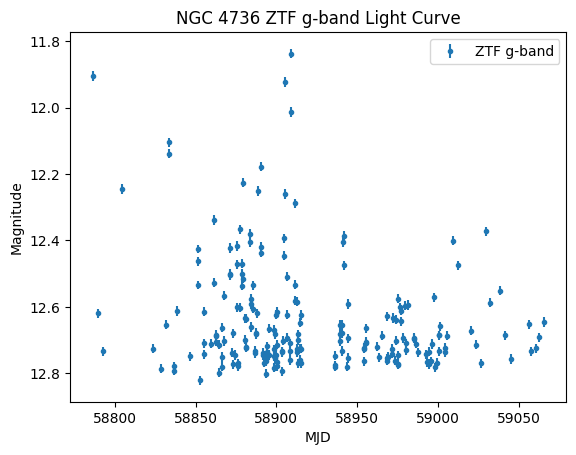

In [ ]:
TARGET_NAME = "NGC 4736"
BAND = "g"
MINJD, MAXJD = 58750, 59100
MINMAG, MAXMAG = 16.0, 17.2
SearchRadius = 0.5 #in arcseconds

coord = SkyCoord.from_name(TARGET_NAME)
ra = coord.ra.deg
dec = coord.dec.deg

# Example usage of the combined function
fetch_and_plot_ztf_lc( ra_deg=ra, dec_deg=dec, radius_arcsec=SearchRadius, bandname=BAND, mjd_min=MINJD, 
                    mjd_max=MAXJD, bad_catflags_mask=0, target_name=TARGET_NAME, min_mag=MINMAG,max_mag=MAXMAG)

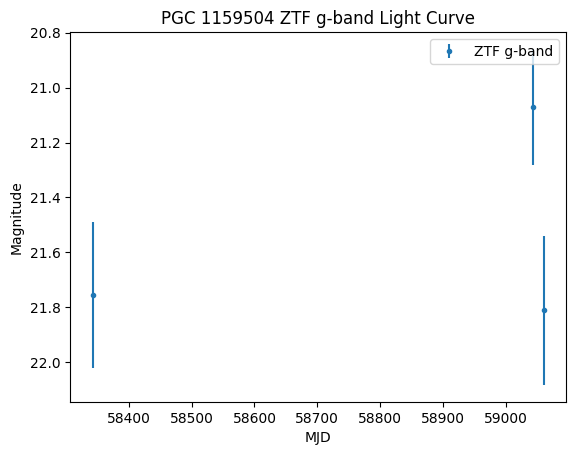

In [ ]:
TARGET_NAME = "PGC 1159504"
BAND = "g"
MINJD, MAXJD = 50000, 59100
MINMAG, MAXMAG = 16.0, 17.2
SearchRadius = 15 #in arcseconds

ra = 358.3134
dec = -0.3511902

# Example usage of the combined function
fetch_and_plot_ztf_lc( ra_deg=ra, dec_deg=dec, radius_arcsec=SearchRadius, bandname=BAND, mjd_min=MINJD, 
                    mjd_max=MAXJD, bad_catflags_mask=0, target_name=TARGET_NAME, min_mag=MINMAG,max_mag=MAXMAG)

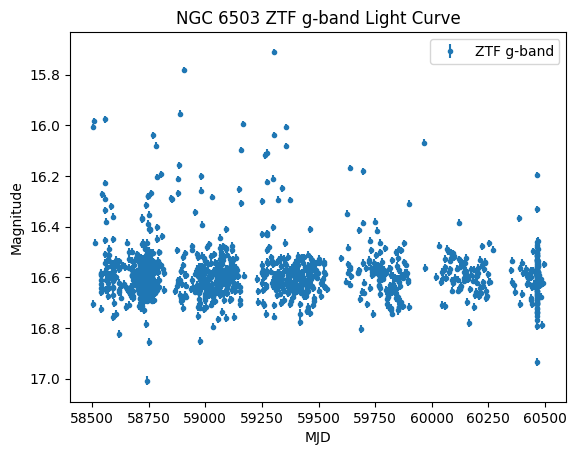

In [ ]:
TARGET_NAME = "NGC 6503"
BAND = "g"
MINJD, MAXJD = 58500, 60500
MINMAG, MAXMAG = 16.0, 17.2
SearchRadius = 0.5 #in arcseconds

coord = SkyCoord.from_name(TARGET_NAME)
ra = coord.ra.deg
dec = coord.dec.deg

# Example usage of the combined function
fetch_and_plot_ztf_lc( ra_deg=ra, dec_deg=dec, radius_arcsec=SearchRadius, bandname=BAND, mjd_min=MINJD, 
                    mjd_max=MAXJD, bad_catflags_mask=0, target_name=TARGET_NAME, min_mag=MINMAG,max_mag=MAXMAG)

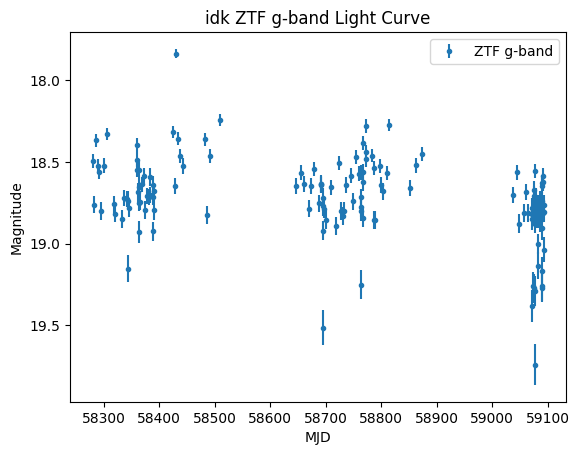

In [ ]:
TARGET_NAME = "idk"
BAND = "g"
MINJD, MAXJD = 45000, 59100
MINMAG, MAXMAG = 16.0, 17.2
SearchRadius = 5 #in arcseconds

ra = 358.728882
dec = 0.410342

# Example usage of the combined function
fetch_and_plot_ztf_lc( ra_deg=ra, dec_deg=dec, radius_arcsec=SearchRadius, bandname=BAND, mjd_min=MINJD, 
                    mjd_max=MAXJD, bad_catflags_mask=0, target_name=TARGET_NAME, min_mag=MINMAG,max_mag=MAXMAG)

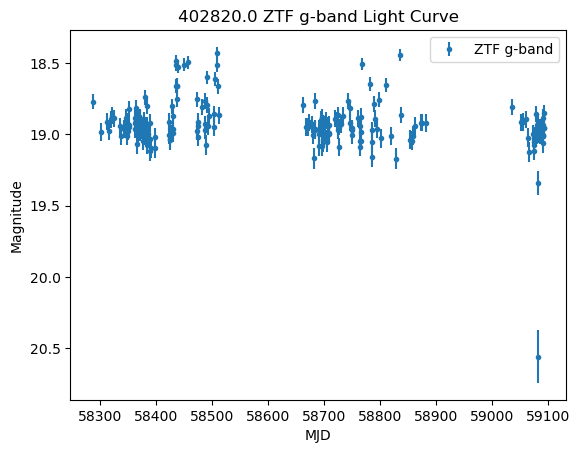

In [7]:
# Look through combined.csv and find the 1st target with agnclass populated, then fetch and plot its ZTF light curve, name should be taken from HyperLeda objname column
df = pd.read_csv('combined.csv')
first_agn_row = df[df['agnclass'].notna()].iloc[0]
TARGET_NAME = first_agn_row['pgc']
BAND = "g"
MINJD, MAXJD = 50000, 59100
MINMAG, MAXMAG = 15, 20
SearchRadius = 8 #in arcseconds
ra = first_agn_row['al2000']
dec = first_agn_row['de2000']
# Example usage of the combined function
fetch_and_plot_ztf_lc( ra_deg=ra, dec_deg=dec, radius_arcsec=SearchRadius, bandname=BAND, mjd_min=MINJD, 
                    mjd_max=MAXJD, bad_catflags_mask=0, target_name=TARGET_NAME, min_mag=MINMAG,max_mag=MAXMAG)
